# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** No report figure. Points in the report figure will be allocated to the report discussion 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Hernando, Claire Marie M. 
- _Student No._: 2024-12904
- _Section_: THR-TX-X

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report discussion

**1.** 
For a hanging mass $M$ supported by two ropes angled at $\alpha$ and $\beta$ relative to the ceiling/horizontal axis, the system is derived from 2D Static Equilibrium ($\sum \mathbf{F} = 0$), wherein:

Horizontal Forces ($\sum F_x = 0$):
$$T_1 \cos(\alpha) - T_2 \cos(\beta) = 0$$Vertical Forces ($\sum F_y = 0$):$$T_1 \sin(\alpha) + T_2 \sin(\beta) = Mg$$

Expressing this system as a matrix equation $A \mathbf{x} = \mathbf{b}$:
$$\begin{bmatrix} \cos(\alpha) & -\cos(\beta) \\ \sin(\alpha) & \sin(\beta) \end{bmatrix} \begin{bmatrix} T_1 \\ T_2 \end{bmatrix} = \begin{bmatrix} 0 \\ Mg \end{bmatrix}$$

**2.**
Upon setting up the matrices, I used np.linalg.solve function from the NumPy library to solve the matrix equation. 

For this function, instead of tackling the full matrix all at once, NumPy splits matrix A into two "triangular" matrices to make it extremely easy to solve since one line gives an answer for a single variable right away. Once splitting is done, NumPy then solves the system into two simple passes: Forward Pass and the Backward Pass. Here, forward pass solves the simplest equation first to find the first variable, while backward pass plugs the first answer back into the remaining equation to instantly get the final variable. Also, NumPy passes the numbers to LAPACK, a set of built-in libraries written in C and Fortran, making the computation faster and more stable. 

### Other comments
I admit I had a hard time putting the function in a Python file for Problem 2 so I consulted AI on how to do this because it seems like if I simply follow the notes, it would result to an error. 


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: (Circuit Analysis)


Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance~$R$.  The power rail at the top is at voltage~$V_+=5$V.  The problem is to find the voltages $V_1...V_N$ at the internal points in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
      
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$

$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form~$A\vec{v} = \vec{w}$ and find the values of the matrix~$A$ and the vector~$\vec{w}$.

3. Write a program to solve for the values of the~$V_i$ when there are $N=6$ internal junctions with unknown voltages.  (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the *solve* function.  You need to make use of the fact that the matrix~$\vec{A}$ is banded.  

### 1.

By Kirchhoff's Current Law, the sum of currents flowing out from a node at potential $V_a$ to an adjacent node at potential $V_b$ through a resistor $R$ is $I = \frac{V_a - V_b}{R}$. To check if $V_1\ldots V_N$ satisfy the equations, we assess each node by looking at its neighboring nodes. 

For $V_1$, it is connected to 3 neighboring nodes: $V_+$, $V_2$, and $V_3$. 

$$\frac{V_1 - V_+}{R} + \frac{V_1 - V_2}{R} + \frac{V_1 - V_3}{R} = 0$$

Multiplying by $R$ and isolating $V_+$ on the right-hand side, we get: 
$$3V_1 - V_2 - V_3 = V_+$$.

This is true for $V_2$ as well. 

Now, for the general interior node $V_i$ ($3 \le i \le N-2$), we can see that it is connected to 4 neighboring nodes (two behind it ($V_{i-2}$ and $V_{i-1}$) and two ahead of it ($V_{i+1}$ and $V_{i+2}$)). So, we have:

$$\frac{V_i - V_{i-2}}{R} + \frac{V_i - V_{i-1}}{R} + \frac{V_i - V_{i+1}}{R} + \frac{V_i - V_{i+2}}{R} = 0$$

Multiplying by $R$ and rearranging terms, we get:
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0$$.

This is true for $V_{N-1}$ too.

Lastly, for $V_N$, it is connected to 3 neighboring nodes ($V_{N-2}$, $V_{N-1}$, and the Ground rail ($0\text{ V}$))> So, we have:

$$\frac{V_N - V_{N-2}}{R} + \frac{V_N - V_{N-1}}{R} + \frac{V_N - 0}{R} = 0$$

Multiplying by $R$ and letting $V_- = 0\text{ V}$, we get:
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0$$

Thus, we can say that using Ohm's law and the Kirchhoff current law, the voltages $V_1\ldots V_N$ satisfy the equations.

### 2.

In [2]:
# Creating a matrix manually

import numpy as np

def matrix_circuit_system(N, V_plus=5.0):
    """
    Expressing the equation in vector form to find the values of the matrix
    and the vector w.
    """

    # Main diagonal (compared with manually written matrix)
    main_diag = 4.0 * np.ones(N)
    main_diag[0] = 3.0 # This is the first element of the diagonal
    main_diag[-1] = 3.0 # This is the last element of the diagonal after N values

    # Off-diagonals 
    off_diag_1 = -1.0 * np.ones(N - 1)
    off_diag_2 = -1.0 * np.ones(N - 2)

    # Creating matrix A from the values above

    A = (np.diag(main_diag) +
        np.diag(off_diag_1, k=1) + np.diag(off_diag_1, k=-1) +
        np.diag(off_diag_2, k=2) + np.diag(off_diag_2, k=-2))

    # Creating vector w as a N x 1 matrix
    w = np.zeros((N, 1))
    w[0, 0] = V_plus
    w[1, 0] = V_plus

    return A, w

# Giving values 
N = 10 # Let's say we have 10 nodes
V_plus = 5.0 # This is given in the problem

A, w = matrix_circuit_system(N, V_plus) 

print ("Matrix A:\n", A)
print ("\nVector w:\n", w)

Matrix A:
 [[ 3. -1. -1.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  4. -1. -1.  0.  0.  0.  0.  0.  0.]
 [-1. -1.  4. -1. -1.  0.  0.  0.  0.  0.]
 [ 0. -1. -1.  4. -1. -1.  0.  0.  0.  0.]
 [ 0.  0. -1. -1.  4. -1. -1.  0.  0.  0.]
 [ 0.  0.  0. -1. -1.  4. -1. -1.  0.  0.]
 [ 0.  0.  0.  0. -1. -1.  4. -1. -1.  0.]
 [ 0.  0.  0.  0.  0. -1. -1.  4. -1. -1.]
 [ 0.  0.  0.  0.  0.  0. -1. -1.  4. -1.]
 [ 0.  0.  0.  0.  0.  0.  0. -1. -1.  3.]]

Vector w:
 [[5.]
 [5.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


### 3.

In [3]:
# Solving the values of V_i where there are N = 6

# Setting up given
N = 6
V_plus = 5.0
A, w = matrix_circuit_system(N, V_plus)

# Solving A * v = w
v = np.linalg.solve(A, w)

print(f"Computed Voltages for N = {N}:")
for i, val in enumerate(v.flatten(), start=1):
    print(f"V_{i} = {val:.4f} V")

# Verification hint check
all_in_range = np.all((v >= 0.0) & (v <= V_plus))
print(f"\nAre all voltages between 0 V and {V_plus} V? {all_in_range}")


Computed Voltages for N = 6:
V_1 = 3.7255 V
V_2 = 3.4314 V
V_3 = 2.7451 V
V_4 = 2.2549 V
V_5 = 1.5686 V
V_6 = 1.2745 V

Are all voltages between 0 V and 5.0 V? True


### 4.

In [4]:
# Creating banded matrix since matrix_circuit_system cannot solve this anymore

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def solve_large_banded_circuit(N=10000, V_plus=5.0):
    # 5 diagonals x N 
    ab = np.zeros((5, N))

    # Row 0: k = +2 (second upper diagonal)
    ab[0, 2:] = -1.0

    # Row 1: k = +1 (first upper diagonal)
    ab[1, 1:] = -1.0

    # Row 2: k = 0 (main diagonal)
    ab[2, :] = 4.0
    ab[2, 0] = 3.0
    ab[2, -1] = 3.0

    # Row 3: k = -1 (first lower diagonal)
    ab[3, :-1] = -1.0

    # Row 4: k = -2 (second lower diagonal)
    ab[4, :-2] = -1.0

    # 2. Right-hand side vector w
    w = np.zeros(N)
    w[0] = V_plus
    w[1] = V_plus

    # 3. Solve banded linear system: (l, u) = (2, 2)
    v = solve_banded((2, 2), ab, w)

    return v

First 5 junction voltages (V_1 ... V_5):
[4.9989 4.9986 4.998  4.9976 4.997 ]

Last 5 junction voltages (V_9996 ... V_10000):
[0.00295  0.002437 0.001972 0.001382 0.001118]


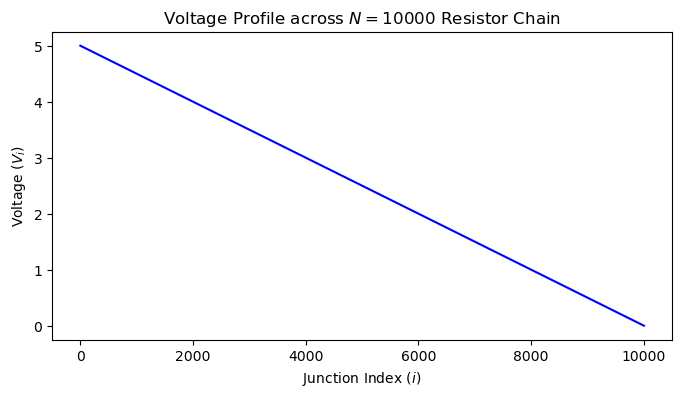

In [5]:
# Solving for N = 10,000 internal junctions

# Run for N = 10,000
N = 10000
V_plus = 5.0

v = solve_large_banded_circuit(N, V_plus)

# Inspect boundary values
print(f"First 5 junction voltages (V_1 ... V_5):")
print(np.round(v[:5], 4))

print(f"\nLast 5 junction voltages (V_{N-4} ... V_{N}):")
print(np.round(v[-5:], 6))

# Plot the voltage distribution along the chain
plt.figure(figsize=(8, 4))
plt.plot(range(1, N + 1), v, color='b', linewidth=1.5)
plt.xlabel("Junction Index ($i$)")
plt.ylabel("Voltage ($V_i$)")
plt.title(f"Voltage Profile across $N = {N}$ Resistor Chain")
plt.grid(False)
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
The script solves for the electric potential $V_i$ across a chain of $N$ interconnected resistors by setting up and solving the system of linear equations $A\vec{v} = \vec{w}$ derived from Kirchhoff's Current Law. In the first few parts, I created a pentadiagonal coefficient matrix $A$ where each row represents a node, and this is okay for lower values of N. However, for N = 10,000, using my first matrix is already inefficient, so I created a banded matrix $ab$ and solved it using scipy.linalg. My functions were confirmed since all calculated voltages lie within the physical boundary conditions ($0\text{ V} \le V_i \le 5\text{ V}$) and I used Matplotlib to plot the voltage drop along the junction index.


### Problem 2 (Statics)


Solve the following matrix problems. Set-up the linear equations that describe the problem then solve them 

Part 1: Suppose you have a hanging mass M supported by two ropes (angled by $\alpha$ and $\beta$ with respect to the ceiling). Make a function that calculates the tension on each of the ropes. Put your function in a python file and call it here in the notebook. Check that the answer by computer matches your own computations.


<del> 
Part 2:
Masses $m_1, m_2, m_3$, and $m_4$ lie on a $2.00$ [m] beam of negligible mass. They are located $0.20, 0.70, 1.10$, and $1.40$ [m] away from the left end of the beam. Determine the masses $m_1, m_2, m_3$, and $m_4$, given the following constraints: 

- The total mass is $8.00$ [kg]
- If a pivot is placed halfway, the beam will balance if a $1.05$ [kg] mass is placed on the right-end of the beam
- If a pivot is placed $1.20$ [m] away from the right end, then the beam would balance if a $550$ [g] mass is placed on the left end of the beam.
- If the system is split midway, the total mass on the left is $1.00$ [kg] heavier than the total mass on the right

</del>

### **Part 1**

In [6]:
%%writefile samplePackage.py

# Making the function that calculates tension on each of the ropes
import numpy as np

def solve_rope_tensions(M, alpha_deg, beta_deg, g=9.8):
    alpha_rad = np.radians(alpha_deg)
    beta_rad = np.radians(beta_deg)

    A = np.array([[np.cos(alpha_rad), -np.cos(beta_rad)], [np.sin(alpha_rad), np.sin(beta_rad)]])
    b = np.array([0, M*g])

    b_transpose = np.transpose(b)

    T1, T2 = np.linalg.solve(A, b_transpose)

    return T1, T2

Overwriting samplePackage.py


In [7]:
%load_ext autoreload
%autoreload 2

import samplePackage as sP

M = 10.0
alpha_deg = 30.0
beta_deg = 60.0
g = 9.8

T1_ans, T2_ans = sP.solve_rope_tensions(M, alpha_deg, beta_deg, g)

print (T1_ans)
print (T2_ans)

49.00000000000001
84.870489570875


In [8]:
# Checking if T1_ans and T2_ans match with manual calculations (T1_man, T2_man)

alpha_rad = np.radians(alpha_deg)
beta_rad = np.radians(beta_deg)

T1_man = (M * g * np.cos(beta_rad)) / np.sin(alpha_rad + beta_rad)
T2_man = (M * g * np.cos(alpha_rad)) / np.sin(alpha_rad + beta_rad)

print (T1_man)
print (T2_man) 

49.000000000000014
84.870489570875


#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

My script started with %%writefile samplePackage.py to save the code directly as a Python file in my system. To make the computation more efficient, I then converted the degrees to radians using np.radians, and built a matrix using np.array.Tension values were solved using np.linalg.solve. I then reloaded the module to make sure Jupyter immediately updates if I make changes inside samplePackage.py, and imported it as sP. I gave values to the variables and solved using sP. To check if the values from my function are correct, I created another function to manually calculate the tensions and compared them. At the end, we can see that manually-computed values and answers by computer match with each other.

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage (Testing different codes)

In [9]:
A = np.array([[1,0,2],[-2,-1,3],[0,3,5]])
B = np.array([[-2],[1],[-3]])


In [10]:
sigma_z = [[1,0],[0,-1]]
sigma_y = [[0,-1j],[1j,0]]
sigma_x = [[0,1],[1,0]]

In [11]:
ans = np.linalg.solve(sigma_x, sigma_y)
ans = np.linalg.inv(A) @ B


In [12]:
from scipy.linalg import *
p, l, u = lu(A)
p, l, u

(array([[0., 0., 1.],
        [1., 0., 0.],
        [0., 1., 0.]]),
 array([[ 1.        ,  0.        ,  0.        ],
        [-0.        ,  1.        ,  0.        ],
        [-0.5       , -0.16666667,  1.        ]]),
 array([[-2.        , -1.        ,  3.        ],
        [ 0.        ,  3.        ,  5.        ],
        [ 0.        ,  0.        ,  4.33333333]]))

### Importing functions from a python file

In [13]:
import samplePackage as sP

In [14]:
testMat = sP.createZerosArray(4,5)

AttributeError: module 'samplePackage' has no attribute 'createZerosArray'

In [ ]:
testMat[1] = [1,2,3,4,5]

In [ ]:
testMat

### np.roll

In [ ]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.zeros((4,4))
x[1,2] = 5
for row in x:
    print(row)

#rint(x[0,1:3])


# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
#x_roll2 = np.roll(x, -1)
print(x_roll)

x_roll2 = np.roll(x, 2)
print(x_roll2)